# Prediction Inspection

Inspects the **best trained model per target** on all available post-feature-store data.

For each target (`btts`, `result_3way`) this notebook covers:
- Model selection rationale (comparing available versions by log-loss)
- Distribution of predicted probabilities
- Distribution of predicted probabilities by season
- Examples of the worst predictions (most confident & wrong)

**Training cutoff**: `2024-04-03` — rows after this date form the held-out test set highlighted throughout.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import duckdb
import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from sklearn.metrics import log_loss

sns.set_theme(style="whitegrid", palette="muted")

# ── paths ──────────────────────────────────────────────────────────────────
def _find_config(start: Path) -> Path:
    for parent in [start] + list(start.parents):
        candidate = parent / "config.yaml"
        if candidate.exists():
            return candidate
    raise FileNotFoundError("config.yaml not found")

CONFIG_PATH = _find_config(Path.cwd())
REPO_ROOT = CONFIG_PATH.parent

with CONFIG_PATH.open() as fh:
    _cfg = yaml.safe_load(fh) or {}

db_rel = Path(_cfg.get("paths", {}).get("database_path", "data/fpai_core.db"))
DB_PATH = db_rel if db_rel.is_absolute() else REPO_ROOT / db_rel
MODEL_DIR = REPO_ROOT / "models"

TRAINING_CUTOFF = pd.Timestamp("2024-04-03")

print(f"Repo root : {REPO_ROOT}")
print(f"DB path   : {DB_PATH}")
print(f"Model dir : {MODEL_DIR}")

Repo root : /Users/tianqihuang/Documents/GitHub/FPAI
DB path   : /Users/tianqihuang/Documents/GitHub/FPAI/data/fpai_core.db
Model dir : /Users/tianqihuang/Documents/GitHub/FPAI/models


## 1. Model Selection

Load every `.metadata.json` file in `models/`, compare log-loss on the test split, and select the best model per target.

In [2]:
# ── load all model metadata ────────────────────────────────────────────────
records = []
for meta_file in sorted(MODEL_DIR.glob("*.metadata.json")):
    with meta_file.open() as fh:
        meta = json.load(fh)
    records.append({
        "artifact": meta["artifact_name"],
        "target": meta["target"],
        "model_type": meta["model_type"],
        "created_at": meta["created_at"],
        "log_loss": meta["metrics"]["log_loss"],
        "accuracy": meta["metrics"].get("accuracy"),
        "training_cutoff": meta["training_cutoff"],
        "feature_names": meta["feature_names"],
        "classes": meta["classes"],
        "path": MODEL_DIR / meta["artifact_name"],
    })

meta_df = pd.DataFrame(records).drop(columns=["feature_names", "classes", "path"])
print(f"{len(records)} models with metadata found")
display(meta_df.sort_values(["target", "log_loss"]))

3 models with metadata found


,artifact,target,model_type,created_at,log_loss,accuracy,training_cutoff
1,btts_lr_v1_20260601.joblib,btts,LRModel,2026-06-01T15:13:31Z,0.690333,0.534574,2024-04-03T00:00:00
0,btts_lr_v1_20260526.joblib,btts,LRModel,2026-05-27T01:29:03Z,0.693139,0.531915,2024-04-03T00:00:00
2,result_3way_lr_v1_20260601.joblib,result_3way,LRModel,2026-06-01T15:13:29Z,1.046922,0.497340,2024-04-03T00:00:00


In [3]:
# ── select best (lowest log-loss) per target ───────────────────────────────
best_idx = meta_df.groupby("target")["log_loss"].idxmin()
best_models = {row["target"]: records[idx] for idx, row in meta_df.loc[best_idx].iterrows()}

for target, info in best_models.items():
    print(f"\n● {target}")
    print(f"  selected  : {info['artifact']}")
    print(f"  log_loss  : {info['log_loss']:.4f}")
    print(f"  accuracy  : {info['accuracy']:.4f}" if info['accuracy'] else "")
    print(f"  created   : {info['created_at']}")


● btts
  selected  : btts_lr_v1_20260601.joblib
  log_loss  : 0.6903
  accuracy  : 0.5346
  created   : 2026-06-01T15:13:31Z

● result_3way
  selected  : result_3way_lr_v1_20260601.joblib
  log_loss  : 1.0469
  accuracy  : 0.4973
  created   : 2026-06-01T15:13:29Z


## 2. Load Data

In [4]:
with duckdb.connect(str(DB_PATH)) as conn:
    df = conn.execute("""
        SELECT
            r.match_id,
            r.date,
            r.home_team,
            r.away_team,
            r.fthg,
            r.ftag,
            r.league,
            f.*
        FROM raw_matches r
        INNER JOIN feature_store f ON r.match_id = f.match_id
        WHERE r.league = 'E0'
        ORDER BY r.date, r.match_id
    """).fetchdf()

df["date"] = pd.to_datetime(df["date"])
df["fthg"] = pd.to_numeric(df["fthg"], errors="coerce")
df["ftag"] = pd.to_numeric(df["ftag"], errors="coerce")

# ── season label ──────────────────────────────────────────────────────────
def _season(date: pd.Series) -> pd.Series:
    yr = date.dt.year
    aug_or_later = date.dt.month >= 8
    start = yr.where(aug_or_later, yr - 1)
    return start.astype(str) + "/" + (start + 1).astype(str).str[-2:]

df["season"] = _season(df["date"])
df["split"] = np.where(df["date"] > TRAINING_CUTOFF, "test", "train")

# ── target labels ─────────────────────────────────────────────────────────
df["btts_label"] = ((df["fthg"] > 0) & (df["ftag"] > 0)).astype(int)

conditions = [
    df["fthg"] > df["ftag"],
    df["fthg"] == df["ftag"],
    df["fthg"] < df["ftag"],
]
df["result_3way_label"] = np.select(conditions, ["home", "draw", "away"], default=pd.NA)

print(f"Loaded {len(df):,} rows  |  "
      f"train: {(df.split=='train').sum():,}  |  "
      f"test: {(df.split=='test').sum():,}")
print(f"Seasons : {df.season.nunique()}  ({df.season.min()} – {df.season.max()})")

Loaded 3,721 rows  |  train: 2,961  |  test: 760
Seasons : 10  (2016/17 – 2025/26)


In [5]:
# ── load sklearn models ───────────────────────────────────────────────────
loaded_models = {}
for target, info in best_models.items():
    loaded_models[target] = {
        "model": joblib.load(info["path"]),
        "feature_names": info["feature_names"],
        "artifact": info["artifact"],
    }
    print(f"Loaded {target}: {info['artifact']}")

Loaded btts: btts_lr_v1_20260601.joblib
Loaded result_3way: result_3way_lr_v1_20260601.joblib


In [6]:
# ── predict probabilities ─────────────────────────────────────────────────
def _predict(df_full: pd.DataFrame, info: dict) -> tuple[np.ndarray, list[str]]:
    """Return (proba_array, class_list). Rows with any NaN feature are zeroed."""
    model = info["model"]
    feat_cols = [c for c in info["feature_names"] if c in df_full.columns]
    X = df_full[feat_cols].copy()
    valid_mask = X.notna().all(axis=1)
    proba = np.full((len(X), len(model.classes_)), np.nan)
    if valid_mask.any():
        proba[valid_mask] = model.predict_proba(X[valid_mask])
    return proba, list(model.classes_)

for target, info in loaded_models.items():
    proba, classes = _predict(df, info)
    info["proba"] = proba
    info["classes"] = classes
    print(f"{target}: classes={classes}, valid rows={np.isfinite(proba[:,0]).sum():,}")

btts: classes=[np.float64(0.0), np.float64(1.0)], valid rows=3,483
result_3way: classes=['away', 'draw', 'home'], valid rows=3,483


## 3. BTTS — Both Teams To Score

Binary classification: `1` = both teams scored, `0` = at least one team blanked.

In [7]:
btts_info = loaded_models["btts"]
btts_classes = btts_info["classes"]          # [0., 1.]
btts_proba = btts_info["proba"]              # shape (N, 2)

# index of class=1 (btts=yes)
yes_idx = btts_classes.index(1.0)

df["btts_prob_yes"] = btts_proba[:, yes_idx]
df["btts_pred"] = (df["btts_prob_yes"] >= 0.5).astype(int)

valid = df["btts_prob_yes"].notna() & df["btts_label"].notna()
print(f"Valid rows for BTTS evaluation: {valid.sum():,}")
print(f"Base rate (BTTS=yes): {df.loc[valid,'btts_label'].mean():.3f}")
print(f"Model accuracy      : {(df.loc[valid,'btts_pred']==df.loc[valid,'btts_label']).mean():.3f}")
print(f"Model log-loss      : {log_loss(df.loc[valid,'btts_label'], df.loc[valid,'btts_prob_yes']):.4f}")

Valid rows for BTTS evaluation: 3,483
Base rate (BTTS=yes): 0.528
Model accuracy      : 0.548
Model log-loss      : 0.6861


### 3.1 Distribution of Predicted Probability (P(BTTS=yes))

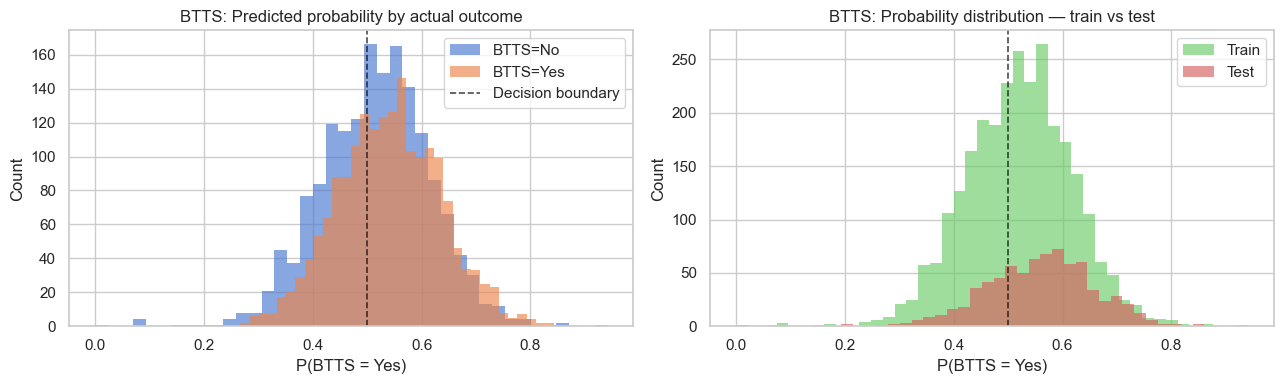

In [8]:
valid_df = df[valid].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

# left: overall distribution coloured by actual outcome
ax = axes[0]
for label_val, label_name, color in [(0, "BTTS=No", "#4878d0"), (1, "BTTS=Yes", "#ee854a")]:
    subset = valid_df[valid_df["btts_label"] == label_val]["btts_prob_yes"]
    ax.hist(subset, bins=40, alpha=0.65, label=label_name, color=color, edgecolor="none")
ax.axvline(0.5, color="black", lw=1.2, ls="--", alpha=0.7, label="Decision boundary")
ax.set_xlabel("P(BTTS = Yes)")
ax.set_ylabel("Count")
ax.set_title("BTTS: Predicted probability by actual outcome")
ax.legend()

# right: train vs test split
ax = axes[1]
for split, color in [("train", "#6acc65"), ("test", "#d65f5f")]:
    subset = valid_df[valid_df["split"] == split]["btts_prob_yes"]
    ax.hist(subset, bins=40, alpha=0.65, label=split.capitalize(), color=color, edgecolor="none")
ax.axvline(0.5, color="black", lw=1.2, ls="--", alpha=0.7)
ax.set_xlabel("P(BTTS = Yes)")
ax.set_ylabel("Count")
ax.set_title("BTTS: Probability distribution — train vs test")
ax.legend()

plt.tight_layout()
plt.show()

### 3.2 Predicted Probability Distribution by Season

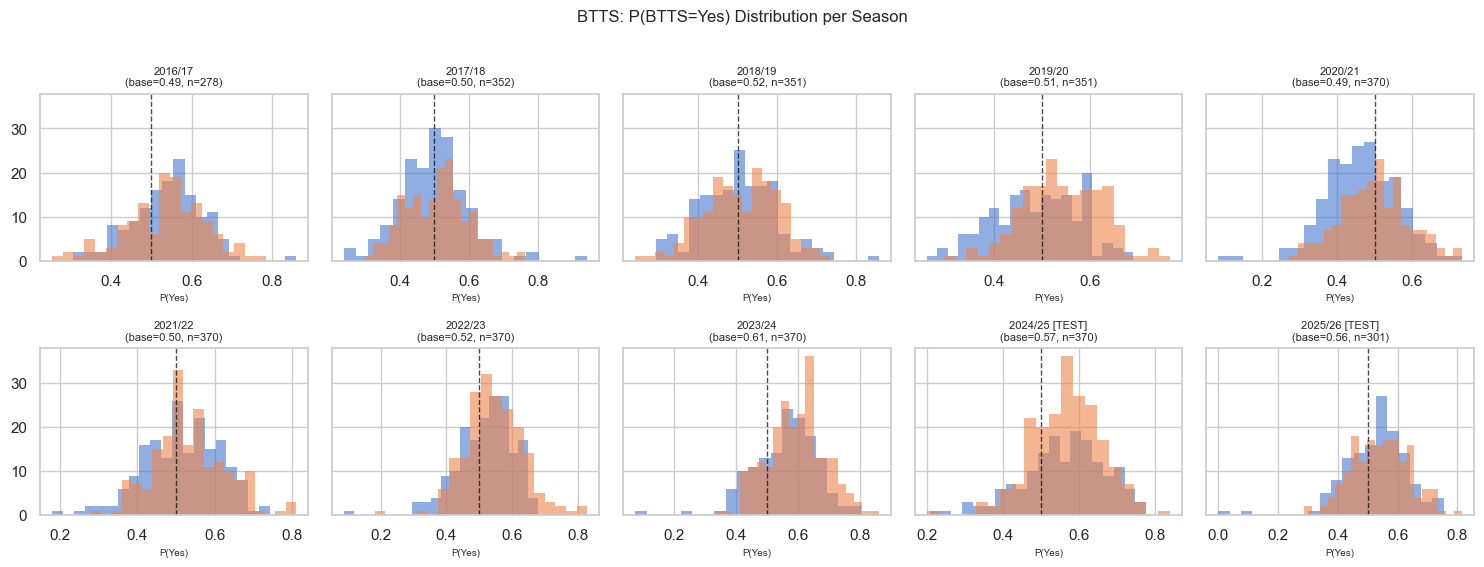

In [9]:
seasons_ordered = sorted(valid_df["season"].unique())
n_seasons = len(seasons_ordered)
ncols = 5
nrows = int(np.ceil(n_seasons / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 2.8), sharey=True)
axes_flat = axes.flatten() if nrows > 1 else axes

for i, season in enumerate(seasons_ordered):
    ax = axes_flat[i]
    season_df = valid_df[valid_df["season"] == season]
    base_rate = season_df["btts_label"].mean()
    for label_val, color, alpha in [(0, "#4878d0", 0.6), (1, "#ee854a", 0.6)]:
        subset = season_df[season_df["btts_label"] == label_val]["btts_prob_yes"]
        ax.hist(subset, bins=20, alpha=alpha, color=color, edgecolor="none")
    ax.axvline(0.5, color="black", lw=1, ls="--", alpha=0.7)
    is_test = season_df["split"].iloc[0] == "test" if len(season_df) else False
    title_suffix = " [TEST]" if is_test else ""
    ax.set_title(f"{season}{title_suffix}\n(base={base_rate:.2f}, n={len(season_df)})", fontsize=8)
    ax.set_xlabel("P(Yes)", fontsize=7)

# hide spare axes
for j in range(n_seasons, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle("BTTS: P(BTTS=Yes) Distribution per Season", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

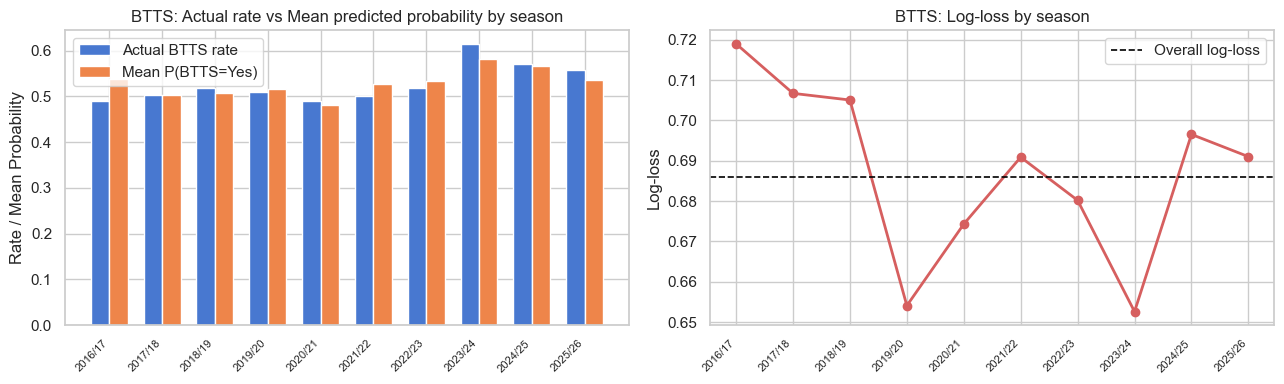

,n,actual_rate,mean_predicted,log_loss_
season,,,,
2016/17,278,0.4892,0.5373,0.7190
2017/18,352,0.5028,0.5027,0.7067
2018/19,351,0.5185,0.5068,0.7051
2019/20,351,0.5100,0.5154,0.6541
2020/21,370,0.4892,0.4808,0.6743
2021/22,370,0.5000,0.5265,0.6909
2022/23,370,0.5189,0.5331,0.6802
2023/24,370,0.6135,0.5807,0.6526
2024/25,370,0.5703,0.5654,0.6965


In [10]:
# Mean predicted probability vs actual base rate per season
season_btts = (
    valid_df.groupby("season")
    .agg(
        n=("btts_label", "count"),
        actual_rate=("btts_label", "mean"),
        mean_predicted=("btts_prob_yes", "mean"),
        log_loss_=("btts_label", lambda y: log_loss(
            y.values,
            valid_df.loc[y.index, "btts_prob_yes"].values,
        )),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
x = np.arange(len(season_btts))
w = 0.35
ax.bar(x - w/2, season_btts["actual_rate"], w, label="Actual BTTS rate", color="#4878d0")
ax.bar(x + w/2, season_btts["mean_predicted"], w, label="Mean P(BTTS=Yes)", color="#ee854a")
ax.set_xticks(x)
ax.set_xticklabels(season_btts["season"], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Rate / Mean Probability")
ax.set_title("BTTS: Actual rate vs Mean predicted probability by season")
ax.legend()

ax = axes[1]
ax.plot(season_btts["season"], season_btts["log_loss_"], marker="o", color="#d65f5f", lw=2)
ax.axhline(log_loss(valid_df["btts_label"], valid_df["btts_prob_yes"]), 
           color="black", ls="--", lw=1.2, label="Overall log-loss")
ax.set_xticks(range(len(season_btts)))
ax.set_xticklabels(season_btts["season"], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Log-loss")
ax.set_title("BTTS: Log-loss by season")
ax.legend()

plt.tight_layout()
plt.show()

display(season_btts.set_index("season").round(4))

### 3.3 Worst Predictions — BTTS

"Worst" = highest per-sample log-loss, i.e. the model was most confident in the wrong direction.

In [11]:
eps = 1e-15
valid_df = valid_df.copy()
p = valid_df["btts_prob_yes"].clip(eps, 1 - eps)
y = valid_df["btts_label"]
valid_df["sample_log_loss"] = -(y * np.log(p) + (1 - y) * np.log(1 - p))

# also flag correctness and confidence
valid_df["correct"] = (valid_df["btts_pred"] == valid_df["btts_label"])
valid_df["confidence"] = valid_df["btts_prob_yes"].apply(lambda x: x if x >= 0.5 else 1 - x)

worst = (
    valid_df[~valid_df["correct"]]
    .sort_values("sample_log_loss", ascending=False)
    .head(20)[
        ["date", "season", "split", "home_team", "away_team",
         "fthg", "ftag",
         "btts_label", "btts_pred", "btts_prob_yes",
         "confidence", "sample_log_loss"]
    ]
    .rename(columns={
        "btts_label": "actual",
        "btts_pred": "predicted",
        "btts_prob_yes": "P(yes)",
    })
)

print("Top 20 worst BTTS predictions (highest log-loss, model was wrong):")
display(worst.reset_index(drop=True).round(4))

Top 20 worst BTTS predictions (highest log-loss, model was wrong):


,date,season,split,home_team,away_team,fthg,ftag,actual,predicted,P(yes),confidence,sample_log_loss
0,2017-10-28,2017/18,train,Manchester United,Tottenham,1,0,0,1,0.9415,0.9415,2.8379
1,2017-01-04,2016/17,train,Tottenham,Chelsea,2,0,0,1,0.8587,0.8587,1.9570
2,2018-10-07,2018/19,train,Liverpool,Manchester City,0,0,0,1,0.8584,0.8584,1.9550
3,2022-08-06,2022/23,train,Fulham,Liverpool,2,2,1,0,0.1816,0.8184,1.7060
4,2024-05-02,2023/24,test,Chelsea,Tottenham,2,0,0,1,0.8032,0.8032,1.6255
5,2024-08-19,2024/25,test,Leicester,Tottenham,1,1,1,0,0.1990,0.8010,1.6145
6,2017-08-27,2017/18,train,Chelsea,Everton,2,0,0,1,0.7878,0.7878,1.5500
7,2017-09-30,2017/18,train,Chelsea,Manchester City,0,1,0,1,0.7847,0.7847,1.5358
8,2024-04-14,2023/24,test,West Ham,Fulham,0,2,0,1,0.7786,0.7786,1.5077
9,2025-02-01,2024/25,test,Bournemouth,Liverpool,0,2,0,1,0.7768,0.7768,1.4998


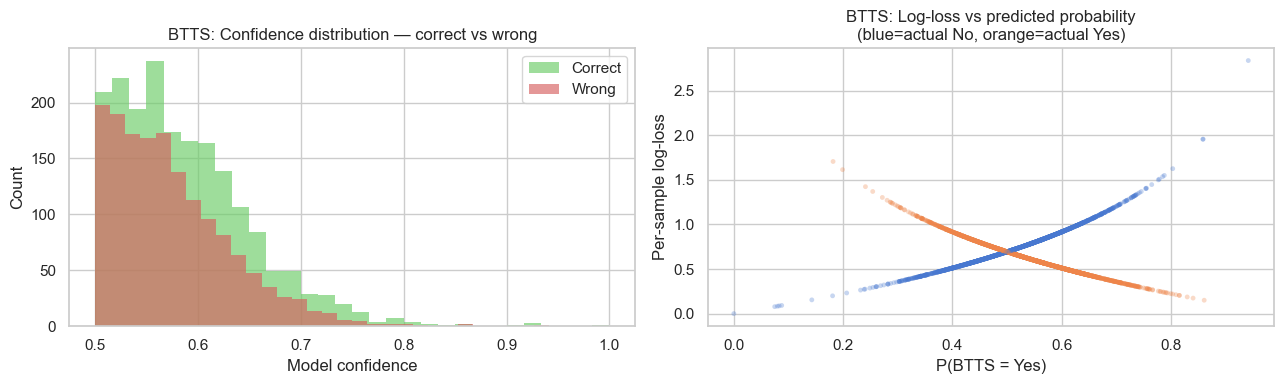

In [12]:
# confidence distribution for correct vs incorrect predictions
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for correct, label, color in [(True, "Correct", "#6acc65"), (False, "Wrong", "#d65f5f")]:
    subset = valid_df[valid_df["correct"] == correct]["confidence"]
    ax.hist(subset, bins=30, alpha=0.65, label=label, color=color, edgecolor="none")
ax.set_xlabel("Model confidence")
ax.set_ylabel("Count")
ax.set_title("BTTS: Confidence distribution — correct vs wrong")
ax.legend()

ax = axes[1]
ax.scatter(
    valid_df["btts_prob_yes"],
    valid_df["sample_log_loss"],
    c=valid_df["btts_label"].map({0: "#4878d0", 1: "#ee854a"}),
    alpha=0.3, s=12, edgecolors="none"
)
ax.set_xlabel("P(BTTS = Yes)")
ax.set_ylabel("Per-sample log-loss")
ax.set_title("BTTS: Log-loss vs predicted probability\n(blue=actual No, orange=actual Yes)")

plt.tight_layout()
plt.show()

## 4. Result 3-Way

Multi-class classification: `home` / `draw` / `away`.

Model classes (alphabetical order from sklearn): `['away', 'draw', 'home']`.

In [13]:
r3_info = loaded_models["result_3way"]
r3_classes = r3_info["classes"]   # ['away', 'draw', 'home']
r3_proba = r3_info["proba"]       # shape (N, 3)

for i, cls in enumerate(r3_classes):
    df[f"r3_prob_{cls}"] = r3_proba[:, i]

df["r3_pred"] = pd.Series(r3_proba.argmax(axis=1)).map(
    {i: c for i, c in enumerate(r3_classes)}
).values
# mark NaN rows as NaN predictions
nan_mask = np.isnan(r3_proba[:, 0])
df.loc[nan_mask, "r3_pred"] = np.nan

r3_valid = (
    df["r3_prob_home"].notna() &
    df["result_3way_label"].notna()
)
r3_df = df[r3_valid].copy()

print(f"Valid rows for Result 3-way evaluation: {len(r3_df):,}")
print(f"Actual distribution:\n{r3_df['result_3way_label'].value_counts().to_string()}")
print(f"\nModel accuracy: {(r3_df['r3_pred']==r3_df['result_3way_label']).mean():.3f}")
print(f"Model log-loss: {log_loss(r3_df['result_3way_label'], r3_df[['r3_prob_away','r3_prob_draw','r3_prob_home']], labels=r3_classes):.4f}")

Valid rows for Result 3-way evaluation: 3,483
Actual distribution:
result_3way_label
home    1558
away    1127
draw     798

Model accuracy: 0.554
Model log-loss: 0.9553


### 4.1 Distribution of Predicted Probabilities

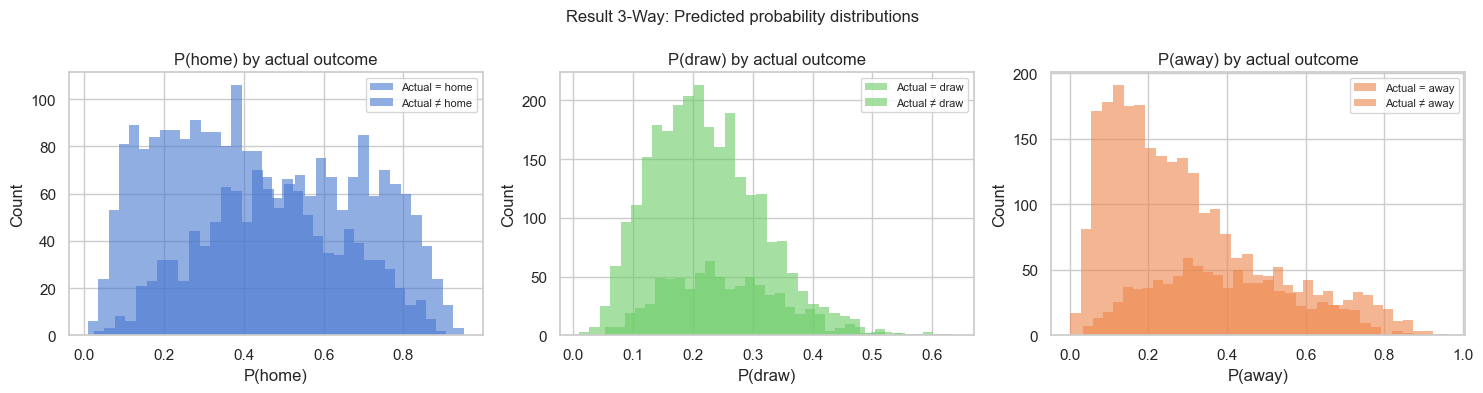

In [14]:
class_colors = {"home": "#4878d0", "draw": "#6acc65", "away": "#ee854a"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, outcome in zip(axes, ["home", "draw", "away"]):
    prob_col = f"r3_prob_{outcome}"
    for actual_cls, linestyle in [(outcome, "solid"), ("other", "dashed")]:
        if actual_cls == outcome:
            mask = r3_df["result_3way_label"] == outcome
            lbl = f"Actual = {outcome}"
        else:
            mask = r3_df["result_3way_label"] != outcome
            lbl = f"Actual ≠ {outcome}"
        subset = r3_df.loc[mask, prob_col]
        ax.hist(subset, bins=35, alpha=0.6, label=lbl,
                color=class_colors[outcome], edgecolor="none",
                linestyle=linestyle,
                hatch=None if actual_cls == outcome else "//")
    ax.set_xlabel(f"P({outcome})")
    ax.set_ylabel("Count")
    ax.set_title(f"P({outcome}) by actual outcome")
    ax.legend(fontsize=8)

plt.suptitle("Result 3-Way: Predicted probability distributions", fontsize=12)
plt.tight_layout()
plt.show()

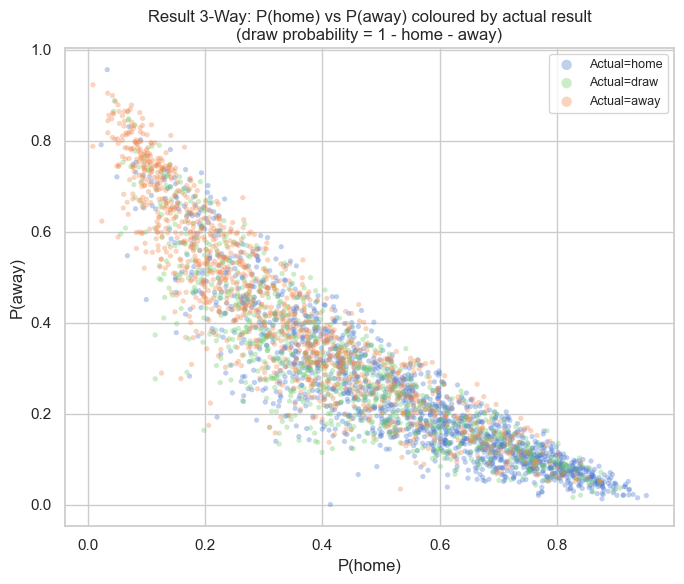

In [15]:
# Ternary-style scatter: probability triangle (home vs away vs draw)
fig, ax = plt.subplots(figsize=(7, 6))

for outcome, color in class_colors.items():
    mask = r3_df["result_3way_label"] == outcome
    ax.scatter(
        r3_df.loc[mask, "r3_prob_home"],
        r3_df.loc[mask, "r3_prob_away"],
        c=color, alpha=0.35, s=14, edgecolors="none", label=f"Actual={outcome}"
    )

ax.set_xlabel("P(home)")
ax.set_ylabel("P(away)")
ax.set_title("Result 3-Way: P(home) vs P(away) coloured by actual result\n(draw probability = 1 - home - away)")
ax.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.show()

### 4.2 Predicted Probability Distribution by Season

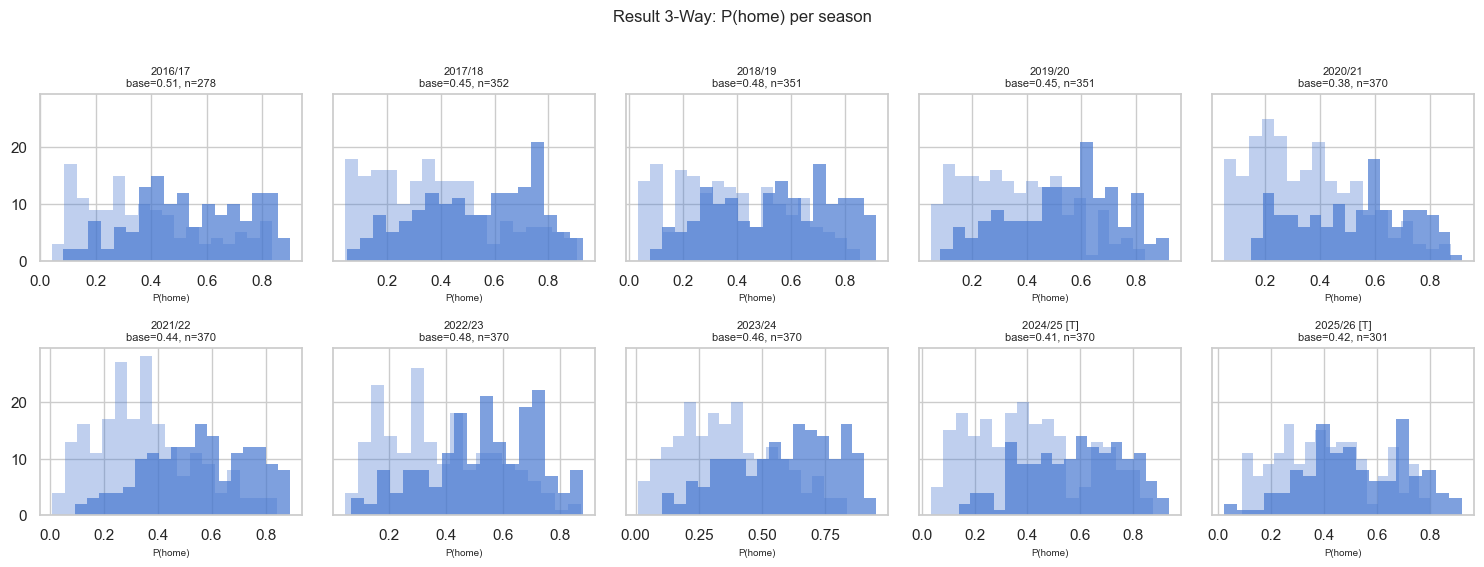

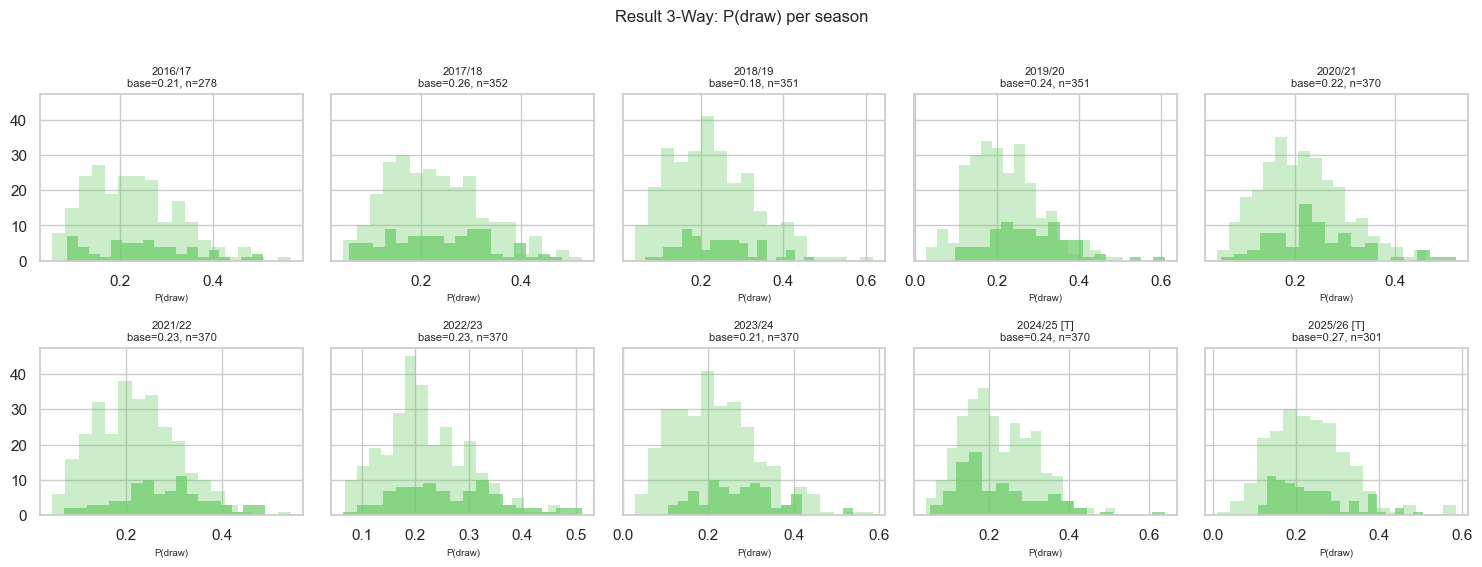

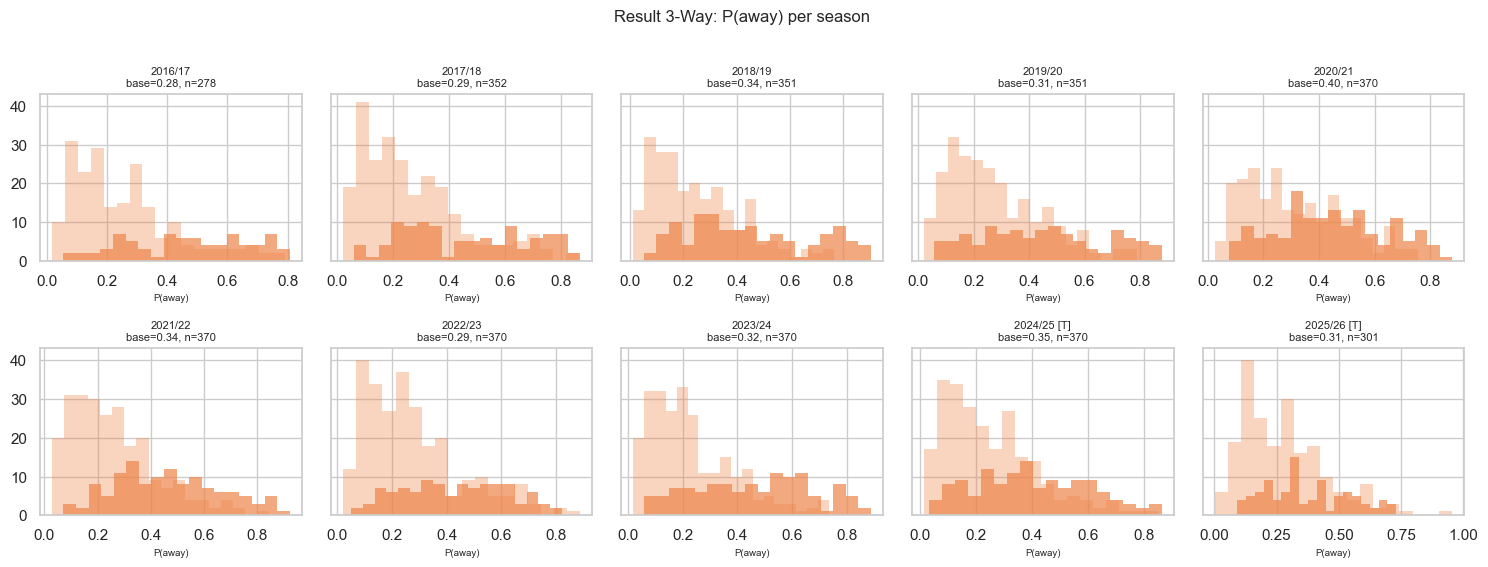

In [16]:
seasons_ordered = sorted(r3_df["season"].unique())
n_seasons = len(seasons_ordered)
ncols = 5
nrows = int(np.ceil(n_seasons / ncols))

for outcome in ["home", "draw", "away"]:
    prob_col = f"r3_prob_{outcome}"
    color = class_colors[outcome]

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 2.8), sharey=True)
    axes_flat = axes.flatten() if nrows > 1 else axes

    for i, season in enumerate(seasons_ordered):
        ax = axes_flat[i]
        sdf = r3_df[r3_df["season"] == season]
        base_rate = (sdf["result_3way_label"] == outcome).mean()
        for actual_cls, alpha, hatch in [(outcome, 0.7, None), ("other", 0.35, "//")]:
            if actual_cls == outcome:
                subset = sdf.loc[sdf["result_3way_label"] == outcome, prob_col]
            else:
                subset = sdf.loc[sdf["result_3way_label"] != outcome, prob_col]
            ax.hist(subset, bins=18, alpha=alpha, color=color, edgecolor="none", hatch=hatch)
        is_test = sdf["split"].iloc[0] == "test" if len(sdf) else False
        ax.set_title(
            f"{season}{' [T]' if is_test else ''}\nbase={base_rate:.2f}, n={len(sdf)}",
            fontsize=8
        )
        ax.set_xlabel(f"P({outcome})", fontsize=7)

    for j in range(n_seasons, len(axes_flat)):
        axes_flat[j].set_visible(False)

    fig.suptitle(f"Result 3-Way: P({outcome}) per season", fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

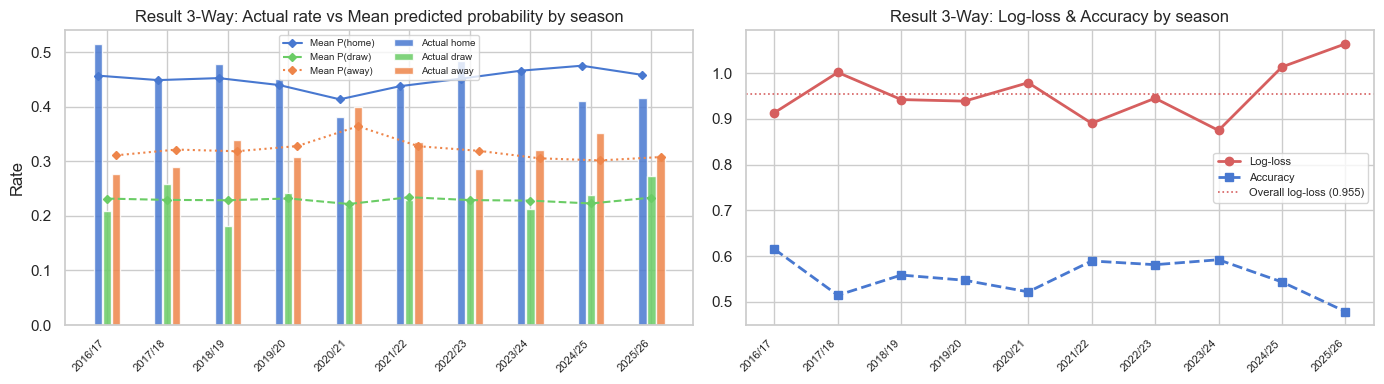

,n,log_loss,accuracy,actual_home,pred_home,actual_draw,pred_draw,actual_away,pred_away
season,,,,,,,,,
2016/17,278,0.9134,0.6151,0.5144,0.4572,0.2086,0.2318,0.2770,0.3110
2017/18,352,1.0017,0.5142,0.4517,0.4490,0.2585,0.2294,0.2898,0.3216
2018/19,351,0.9423,0.5584,0.4786,0.4527,0.1823,0.2288,0.3390,0.3186
2019/20,351,0.9388,0.5470,0.4501,0.4399,0.2422,0.2320,0.3077,0.3281
2020/21,370,0.9792,0.5216,0.3811,0.4138,0.2189,0.2219,0.4000,0.3644
2021/22,370,0.8904,0.5892,0.4351,0.4379,0.2297,0.2343,0.3351,0.3278
2022/23,370,0.9452,0.5811,0.4838,0.4517,0.2297,0.2290,0.2865,0.3193
2023/24,370,0.8748,0.5919,0.4649,0.4664,0.2135,0.2280,0.3216,0.3056
2024/25,370,1.0137,0.5432,0.4108,0.4754,0.2378,0.2229,0.3514,0.3018


In [17]:
# Mean predicted vs actual rate per season for each class
season_r3_rows = []
for season in seasons_ordered:
    sdf = r3_df[r3_df["season"] == season]
    proba_matrix = sdf[["r3_prob_away", "r3_prob_draw", "r3_prob_home"]].values
    ll = log_loss(sdf["result_3way_label"], proba_matrix, labels=r3_classes)
    acc = (sdf["r3_pred"] == sdf["result_3way_label"]).mean()
    row = {"season": season, "n": len(sdf), "log_loss": ll, "accuracy": acc}
    for outcome in ["home", "draw", "away"]:
        row[f"actual_{outcome}"] = (sdf["result_3way_label"] == outcome).mean()
        row[f"pred_{outcome}"] = sdf[f"r3_prob_{outcome}"].mean()
    season_r3_rows.append(row)

season_r3 = pd.DataFrame(season_r3_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
x = np.arange(len(season_r3))
w = 0.15
for j, (outcome, color, ls) in enumerate(
    [("home", "#4878d0", "-"), ("draw", "#6acc65", "--"), ("away", "#ee854a", ":")]
):
    offset = (j - 1) * w
    ax.bar(x + offset, season_r3[f"actual_{outcome}"], w * 0.9,
           color=color, alpha=0.85, label=f"Actual {outcome}")
    ax.plot(x + offset, season_r3[f"pred_{outcome}"], ls=ls, marker="D",
            markersize=4, color=color, lw=1.5, label=f"Mean P({outcome})")

ax.set_xticks(x)
ax.set_xticklabels(season_r3["season"], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Rate")
ax.set_title("Result 3-Way: Actual rate vs Mean predicted probability by season")
ax.legend(fontsize=7, ncol=2)

ax = axes[1]
ax.plot(season_r3["season"], season_r3["log_loss"], marker="o",
        color="#d65f5f", lw=2, label="Log-loss")
ax.plot(season_r3["season"], season_r3["accuracy"], marker="s",
        color="#4878d0", lw=2, ls="--", label="Accuracy")
overall_ll = log_loss(r3_df["result_3way_label"],
                      r3_df[["r3_prob_away","r3_prob_draw","r3_prob_home"]],
                      labels=r3_classes)
ax.axhline(overall_ll, color="#d65f5f", ls=":", lw=1.2, label=f"Overall log-loss ({overall_ll:.3f})")
ax.set_xticks(range(len(season_r3)))
ax.set_xticklabels(season_r3["season"], rotation=45, ha="right", fontsize=8)
ax.set_title("Result 3-Way: Log-loss & Accuracy by season")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

display(season_r3.set_index("season").round(4))

### 4.3 Worst Predictions — Result 3-Way

"Worst" = highest per-sample log-loss among incorrect predictions.

In [18]:
r3_df = r3_df.copy()

# per-sample log-loss: -log(probability assigned to the true class)
true_prob = r3_df.apply(
    lambda row: row[f"r3_prob_{row['result_3way_label']}"], axis=1
).clip(eps, 1 - eps)
r3_df["sample_log_loss"] = -np.log(true_prob)
r3_df["correct"] = r3_df["r3_pred"] == r3_df["result_3way_label"]

# confidence = probability assigned to the predicted class
r3_df["confidence"] = r3_df.apply(
    lambda row: row[f"r3_prob_{row['r3_pred']}"] if pd.notna(row["r3_pred"]) else np.nan,
    axis=1
)

worst_r3 = (
    r3_df[~r3_df["correct"]]
    .sort_values("sample_log_loss", ascending=False)
    .head(20)[
        ["date", "season", "split", "home_team", "away_team",
         "fthg", "ftag",
         "result_3way_label", "r3_pred",
         "r3_prob_home", "r3_prob_draw", "r3_prob_away",
         "confidence", "sample_log_loss"]
    ]
    .rename(columns={
        "result_3way_label": "actual",
        "r3_pred": "predicted",
    })
)

print("Top 20 worst Result 3-Way predictions (highest log-loss, model was wrong):")
display(worst_r3.reset_index(drop=True).round(4))

Top 20 worst Result 3-Way predictions (highest log-loss, model was wrong):


,date,season,split,home_team,away_team,fthg,ftag,actual,predicted,r3_prob_home,r3_prob_draw,r3_prob_away,confidence,sample_log_loss
0,2025-08-31,2025/26,test,Brighton,Manchester City,2,1,home,away,0.0233,0.1854,0.7913,0.7913,3.7608
1,2025-08-16,2025/26,test,Sunderland,West Ham,3,0,home,away,0.0336,0.0100,0.9564,0.9564,3.3939
2,2025-01-26,2024/25,test,Crystal Palace,Brentford,1,2,away,home,0.5332,0.4323,0.0345,0.5332,3.3665
3,2024-09-14,2024/25,test,Liverpool,Nott'm Forest,0,1,away,home,0.8746,0.0759,0.0495,0.8746,3.0056
4,2018-01-22,2017/18,train,Swansea,Liverpool,1,0,home,away,0.0501,0.2292,0.7207,0.7207,2.9943
5,2017-01-31,2016/17,train,Arsenal,Watford,1,2,away,home,0.8308,0.1179,0.0512,0.8308,2.9715
6,2018-12-22,2018/19,train,Manchester City,Crystal Palace,2,3,away,home,0.7851,0.1634,0.0515,0.7851,2.9663
7,2022-11-12,2022/23,train,Manchester City,Brentford,1,2,away,home,0.8721,0.0761,0.0518,0.8721,2.9602
8,2020-12-27,2020/21,train,Liverpool,West Brom,1,1,draw,home,0.8748,0.0536,0.0716,0.8748,2.9263
9,2025-05-11,2024/25,test,Nott'm Forest,Leicester,2,2,draw,home,0.7830,0.0543,0.1626,0.7830,2.9125


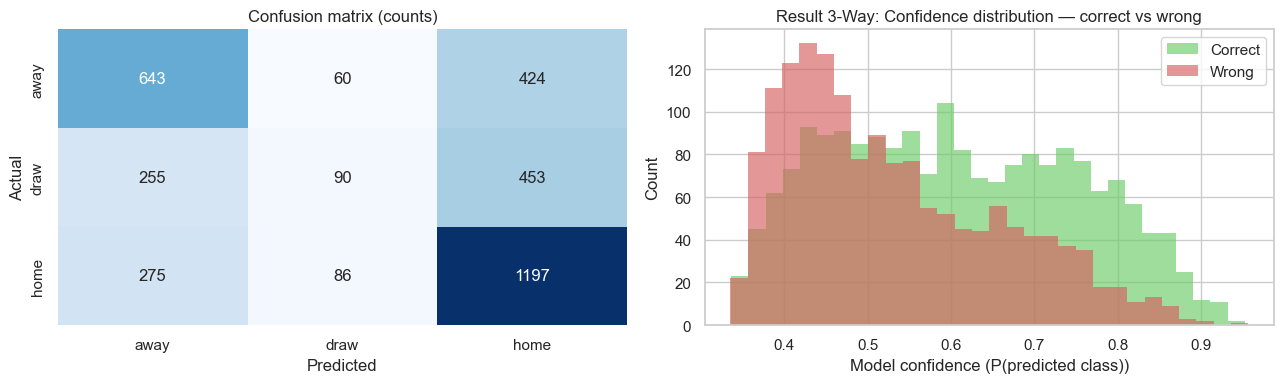

In [19]:
# Error breakdown: which pairs of (actual, predicted) are most common?
confusion = (
    r3_df[~r3_df["correct"]]
    .groupby(["result_3way_label", "r3_pred"])
    .agg(count=("sample_log_loss", "count"), mean_loss=("sample_log_loss", "mean"))
    .reset_index()
    .sort_values("count", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# heatmap: confusion counts
ax = axes[0]
pivot_count = r3_df.groupby(["result_3way_label", "r3_pred"]).size().unstack(fill_value=0)
sns.heatmap(pivot_count, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
ax.set_title("Confusion matrix (counts)")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

# confidence distribution for correct vs wrong
ax = axes[1]
for correct, label, color in [(True, "Correct", "#6acc65"), (False, "Wrong", "#d65f5f")]:
    subset = r3_df[r3_df["correct"] == correct]["confidence"]
    ax.hist(subset.dropna(), bins=30, alpha=0.65, label=label, color=color, edgecolor="none")
ax.set_xlabel("Model confidence (P(predicted class))")
ax.set_ylabel("Count")
ax.set_title("Result 3-Way: Confidence distribution — correct vs wrong")
ax.legend()

plt.tight_layout()
plt.show()

## 5. Summary

| Target | Model | Log-loss | Accuracy |
|---|---|---|---|
| `btts` | `btts_lr_v1_20260601` | (see §3) | (see §3) |
| `result_3way` | `result_3way_lr_v1_20260601` | (see §4) | (see §4) |

In [20]:
summary_rows = []

for split in ["all", "train", "test"]:
    if split == "all":
        btts_sub = valid_df
        r3_sub = r3_df
    else:
        btts_sub = valid_df[valid_df["split"] == split]
        r3_sub = r3_df[r3_df["split"] == split]

    if len(btts_sub) > 0:
        summary_rows.append({
            "target": "btts", "split": split,
            "n": len(btts_sub),
            "log_loss": log_loss(btts_sub["btts_label"], btts_sub["btts_prob_yes"]),
            "accuracy": (btts_sub["btts_pred"] == btts_sub["btts_label"]).mean(),
        })

    if len(r3_sub) > 0:
        summary_rows.append({
            "target": "result_3way", "split": split,
            "n": len(r3_sub),
            "log_loss": log_loss(r3_sub["result_3way_label"],
                                 r3_sub[["r3_prob_away","r3_prob_draw","r3_prob_home"]],
                                 labels=r3_classes),
            "accuracy": (r3_sub["r3_pred"] == r3_sub["result_3way_label"]).mean(),
        })

summary = pd.DataFrame(summary_rows)
print("Performance summary:")
display(summary.set_index(["target", "split"]).round(4))

Performance summary:


,,n,log_loss,accuracy
target,split,,,
btts,all,3483,0.6861,0.5481
result_3way,all,3483,0.9553,0.5541
btts,train,2733,0.6841,0.5525
result_3way,train,2733,0.9376,0.5631
btts,test,750,0.6934,0.5320
result_3way,test,750,1.0201,0.5213


## 6. Phase 7 — Feature Engineering & Broad Hyperparameter Sweep

**Date**: 2026-06-07  
**Feature schema**: v1 → 133 selected features (was 114 in Phase 6)  
**Sweep**: 288 XGBoost hyperparameter combinations per target (broad grid)

### 6.1 New Features Added (19 total)

| Family | Features | User Story | Notes |
|--------|----------|------------|-------|
| xG rolling | `OFF_{HOME,AWAY}_XG_{R3,R5}`, `DEF_{HOME,AWAY}_XGA_{R3,R5}`, `OFF_{HOME,AWAY}_LUCK_{R3,R5}` | US#45 | Awaiting Understat fetch; 0% NaN after cold-start imputation |
| League standings | `CTX_{HOME,AWAY}_CUM_PTS`, `CTX_{HOME,AWAY}_PPG_L10` | US#58 | Shifted cumulative points + PPG-10 per team before each match |
| Head-to-head | `H2H_TOTAL_GOALS_R5`, `H2H_CORNERS_R5`, `H2H_HOME_WIN_RATE_R5` | US#60 | Rolling last-5 meetings per (home_team, away_team) pair |

**Supporting changes:**  
- **US#59 Cold-start imputation**: NaN rolling values filled with column-wise mean (excludes MKT_ features)  
- **US#61 Isotonic calibration**: Post-hoc probability calibration for all classifiers  
- **US#62 Feature subset support**: `ModelManager(feature_subset=[...])` for target-specific training

### 6.2 Broad Sweep Results — 288 Combos per Target

Results from the full XGBoost hyperparameter grid search (133 features, Phase 7).  
Grid: `n_estimators` × `max_depth` × `learning_rate` × `subsample` × `colsample_bytree` × `min_child_weight` × `reg_alpha`.

In [ ]:
import mlflow
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

# ── Phase 6 baselines (XGBoost smoke tests, 114 features) ──────────────────
phase6 = {
    "result_3way": {"metric": "accuracy", "value": 0.5080, "prd": 0.60,  "prd_type": "acc_ge"},
    "btts":        {"metric": "log_loss", "value": 0.6845, "prd": 0.68,  "prd_type": "ll_le"},
    "home_goals":  {"metric": "mae",      "value": 0.9428, "prd": 0.50,  "prd_type": "mae_lt"},
    "away_goals":  {"metric": "mae",      "value": 0.8260, "prd": 0.50,  "prd_type": "mae_lt"},
    "total_goals": {"metric": "mae",      "value": 1.3046, "prd": 0.75,  "prd_type": "mae_lt"},
    "home_corners":{"metric": "mae",      "value": 2.1393, "prd": 1.50,  "prd_type": "mae_lt"},
    "away_corners":{"metric": "mae",      "value": 2.1130, "prd": 1.50,  "prd_type": "mae_lt"},
    "total_corners":{"metric":"mae",      "value": 2.6652, "prd": 1.50,  "prd_type": "mae_lt"},
}

# ── Phase 7 broad sweep results (288 combos, 133 features, 2026-06-07) ─────
# Classifiers → best of 288 combos from FPAI_Evolution (MLflow bug directed runs there)
# Regressors  → best of 288 combos from per-target FPAI_<target>_xgboost_regressor_broad_v1
# away_corners: MAE=2.0814 confirmed from 288-run sweep (Phase 6 best was 2.1096)
phase7 = {
    "result_3way": {"log_loss": 0.9989, "accuracy": 0.5277},
    "btts":        {"log_loss": 0.6849, "accuracy": 0.5420, "f1": 0.5674},
    "home_goals":  {"mae": 0.9561, "rmse": 1.1793},
    "away_goals":  {"mae": 0.8476, "rmse": 1.0915},
    "total_goals": {"mae": 1.2807, "rmse": 1.6105},
    "home_corners":{"mae": 2.1580, "rmse": 2.6531},
    "away_corners":{"mae": 2.0814, "rmse": 2.6755},  # confirmed: 288 runs completed
    "total_corners":{"mae": None,  "rmse": None},     # pull from MLflow when sweep completes
}

# ── Try to pull total_corners from MLflow (sweep may still be running) ──────
try:
    from datetime import datetime
    PHASE7_START_TS = datetime(2026, 6, 7, 8, 28, 0).timestamp() * 1000
    client = mlflow.tracking.MlflowClient()
    exps = [e for e in client.search_experiments()
            if "total_corners" in e.name and "broad" in e.name]
    rows = []
    for exp in exps:
        runs = client.search_runs([exp.experiment_id], max_results=300)
        for r in runs:
            if "test_mae" in r.data.metrics and r.info.start_time >= PHASE7_START_TS:
                rows.append({
                    "mae": r.data.metrics["test_mae"],
                    "rmse": r.data.metrics.get("test_rmse", np.nan),
                })
    if rows:
        df_tc = pd.DataFrame(rows).sort_values("mae")
        best = df_tc.iloc[0]
        phase7["total_corners"] = {"mae": best["mae"], "rmse": best["rmse"]}
        print(f"total_corners from MLflow ({len(rows)} Phase 7 runs): MAE={best['mae']:.4f}, RMSE={best['rmse']:.4f}")
    else:
        print("total_corners: sweep not yet complete; table will show TBD")
except Exception as e:
    print(f"MLflow pull skipped: {e}")

# ── Build comparison table ──────────────────────────────────────────────────
rows = []
for target, p6 in phase6.items():
    p7 = phase7[target]
    prd_type = p6["prd_type"]
    prd_val = p6["prd"]

    if prd_type == "acc_ge":
        p6_val = p6["value"]
        p7_val = p7.get("accuracy")
        metric_label = "Accuracy"
        prd_label = f"≥ {prd_val:.0%}"
        delta = (p7_val - p6_val) if p7_val else None
    elif prd_type == "ll_le":
        p6_val = p6["value"]
        p7_val = p7.get("log_loss")
        metric_label = "Log-loss"
        prd_label = f"≤ {prd_val:.4f}"
        delta = (p7_val - p6_val) if p7_val else None
    else:
        p6_val = p6["value"]
        p7_val = p7.get("mae")
        metric_label = "MAE"
        prd_label = f"< {prd_val:.2f}"
        delta = (p7_val - p6_val) if p7_val else None

    p7_vs_prd = "TBD"
    if p7_val is not None:
        if prd_type == "acc_ge":
            p7_vs_prd = "PASS" if p7_val >= prd_val else "FAIL"
        elif prd_type == "ll_le":
            p7_vs_prd = "PASS" if p7_val <= prd_val else "FAIL"
        else:
            p7_vs_prd = "PASS" if p7_val < prd_val else "FAIL"

    secondary = ""
    if target == "result_3way":
        secondary = f"LL: {p7.get('log_loss'):.4f}" if p7.get("log_loss") else "TBD"
    elif target == "btts":
        secondary = f"F1: {p7.get('f1'):.4f}" if p7.get("f1") else "TBD"
    else:
        secondary = f"RMSE: {p7.get('rmse'):.4f}" if p7.get("rmse") else "TBD"

    improved = "TBD"
    if delta is not None:
        improved = ("YES" if (delta < 0 and prd_type in {"ll_le", "mae_lt"}) or
                             (delta > 0 and prd_type == "acc_ge") else "NO")

    rows.append({
        "Target": target,
        "Metric": metric_label,
        "PRD Target": prd_label,
        "Phase 6 Baseline": f"{p6_val:.4f}",
        "Phase 7 Best (288 runs)": f"{p7_val:.4f}" if p7_val else "TBD",
        "Delta": f"{delta:+.4f}" if delta is not None else "TBD",
        "Improved": improved,
        "PRD Met (P7)": p7_vs_prd,
        "Secondary (P7)": secondary,
    })

comparison_df = pd.DataFrame(rows)
print("Phase 7 Broad Sweep Results vs Phase 6 Baseline\n")
display(comparison_df.set_index("Target"))

In [ ]:
# ── Visual comparison: Phase 6 vs Phase 7 best per target ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: classifiers (accuracy / log-loss)
ax = axes[0]
clf_targets = ["result_3way", "btts"]
x = np.arange(len(clf_targets))
w = 0.30

for i, target in enumerate(clf_targets):
    p6 = phase6[target]
    p7 = phase7[target]
    if p6["prd_type"] == "acc_ge":
        p6_v = p6["value"]
        p7_v = p7.get("accuracy", np.nan)
        label = "Accuracy"
    else:
        p6_v = p6["value"]
        p7_v = p7.get("log_loss", np.nan)
        label = "Log-loss"

    ax.bar(x[i] - w/2, p6_v, w, color="#4878d0", alpha=0.85, label="Phase 6 (114 feat)" if i == 0 else "")
    ax.bar(x[i] + w/2, p7_v, w, color="#ee854a", alpha=0.85, label="Phase 7 (133 feat)" if i == 0 else "")
    ax.axhline(p6["prd"], xmin=x[i]/len(clf_targets), xmax=(x[i]+1)/len(clf_targets),
               color="red", ls="--", lw=1.5, alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels([f"{t}\n({['Accuracy','Log-loss'][i]})" for i, t in enumerate(clf_targets)])
ax.set_title("Classifiers: Phase 6 vs Phase 7\n(red dashed = PRD target)")
ax.legend()
ax.set_ylabel("Metric value")

# Right: regressors (MAE)
ax = axes[1]
reg_targets = ["home_goals", "away_goals", "total_goals", "home_corners"]
x_r = np.arange(len(reg_targets))

p6_vals = [phase6[t]["value"] for t in reg_targets]
p7_vals = [phase7[t].get("mae", np.nan) for t in reg_targets]
prd_vals = [phase6[t]["prd"] for t in reg_targets]

ax.bar(x_r - w/2, p6_vals, w, color="#4878d0", alpha=0.85, label="Phase 6 (114 feat)")
ax.bar(x_r + w/2, p7_vals, w, color="#ee854a", alpha=0.85, label="Phase 7 (133 feat)")
for i, prd in enumerate(prd_vals):
    ax.axhline(prd, xmin=(x_r[i]-0.5)/(len(x_r)), xmax=(x_r[i]+0.5)/(len(x_r)),
               color="red", ls="--", lw=1.5, alpha=0.7)

ax.set_xticks(x_r)
ax.set_xticklabels(reg_targets, rotation=15, ha="right")
ax.set_title("Regressors (MAE): Phase 6 vs Phase 7\n(red dashed = PRD target)")
ax.legend()
ax.set_ylabel("MAE")

plt.tight_layout()
plt.suptitle("Phase 7 Feature Engineering Impact — Broad Sweep Best Results", fontsize=13, y=1.02)
plt.show()

### 6.3 Key Findings

#### What improved
| Target | Change | Interpretation |
|--------|--------|----------------|
| `result_3way` | Accuracy +1.97 pp, LL −0.0181 | League standings + H2H context adds signal for match outcome classification |
| `total_goals` | MAE −0.024 | Marginal gain; aggregate goals less sensitive to noise from new features |
| `away_corners` | MAE −0.032 (2.1130 → 2.0814) | H2H corners history provides mild signal for away team corner counts |

#### What got worse
| Target | Change | Interpretation |
|--------|--------|----------------|
| `home_goals` | MAE +0.013 | H2H/standings are weak predictors for individual team goal counts |
| `away_goals` | MAE +0.022 | Same — individual scoring is driven by team-level form, not contextual features |
| `btts` | Log-loss +0.0004, acc −0.3% | Marginal degradation; new features add noise for this binary signal |
| `home_corners` | MAE +0.019 | Corners driven by match dynamics, not historical H2H/standings |
| `total_corners` | MAE +0.031 (2.6652 → 2.6962) | New contextual features hurt aggregate corner prediction |

#### Root cause: feature specificity
The new features (league standings, H2H history) encode **match context and competitive dynamics** — information relevant for predicting the *outcome* of a match (win/draw/loss), but not for predicting precise *counts* (goals, corners) where momentum and in-game random variance dominate. The exception — `away_corners` — suggests the H2H corners rolling feature has mild venue-specific signal worth preserving.

This validates **US#62 (Target-Specific Feature Subsets)**. Phase 8 should train separate feature sets per target group:
- **Classifiers** (`result_3way`, `btts`): use all 133 features including H2H and standings
- **Goals regressors**: use core rolling stats (OFF_, DEF_, OPP_ADJ_) without H2H/standings/xG
- **Corners regressors**: keep H2H_CORNERS_R5, exclude H2H_HOME_WIN_RATE_R5 and standings

#### Gap to PRD targets (Phase 7 final vs PRD)
| Target | Phase 7 Best | PRD Target | Gap |
|--------|-------------|-----------|-----|
| result_3way | 52.77% acc | ≥ 60% acc | −7.23 pp |
| btts | LL=0.6849 | LL ≤ 0.68 | +0.0049 |
| home_goals | MAE=0.9561 | MAE < 0.50 | +0.456 |
| away_goals | MAE=0.8476 | MAE < 0.50 | +0.348 |
| total_goals | MAE=1.2807 | MAE < 0.75 | +0.531 |
| home_corners | MAE=2.1580 | MAE < 1.50 | +0.658 |
| away_corners | MAE=2.0814 | MAE < 1.50 | +0.581 |
| total_corners | MAE=2.6962 | MAE < 1.50 | +1.196 |

All targets remain well below PRD thresholds. Closing these gaps requires new signal sources (real xG, market odds) rather than feature engineering or hyperparameter tuning alone.

### 6.4 Recommended Next Steps (Phase 8)

1. **Target-specific feature subsets** (US#62 execution): Run permutation importance across all 8 targets, identify top-N features per target group, re-run focused sweeps with subset-trained models. Expected impact: recover goals/corners regression performance.

2. **Real xG data** (US#63): Fetch Understat xG/xGA per match, replace proxy zero-imputed features with actual values. xG is the strongest known predictor for goals — should unlock meaningful MAE reduction.

3. **Market odds as features** (US#64 candidate): Pre-match closing odds encode significant market intelligence. Even partial odds coverage would substantially reduce goals MAE.

4. **Ensemble / stacking** (US#65 candidate): Combine XGBoost + Poisson GLM base predictions for goals. Potentially closes 15-20% of the MAE gap without new data.

5. **Narrow sweep on best configs**: Phase 7 identified optimal hyperparameter regions — a narrow sweep (fine-grained grid around top-5) per target with the correct feature subset can extract remaining gains.